In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
import ot
import pandas as pd
import time
import random
from gwgraphs import *

In [2]:
np.random.seed(42)
random.seed(42)

In [3]:
# ERSBM1 Experiments
prob_matrix = [
    [0.15, 0.05],  # Probabilities related to block 1 connections
    [0.05, 0.15]  # Probabilities related to block 2 connections
]

graphs_er = generate_erdos_renyi_graphs(100, 100, 0.1)
graphs_sbm = generate_sbm_graphs(100, [50, 50], prob_matrix)

full_graph_data = graphs_er + graphs_sbm
# Convert graphs to pairwise distance matrices
distance_matrices = [
    compute_distance_matrix(graph) for graph, label in full_graph_data
]
# Prepare labels
labels = [label for graph, label in full_graph_data]

In [4]:
# ERSBM2 Experiments
prob_matrix2 = [
    [0.45, 0.05],  # Probabilities related to block 1 connections
    [0.05, 0.45]  # Probabilities related to block 2 connections
]

graphs_er5 = generate_erdos_renyi_graphs(100, 100, 0.25)
graphs_sbm5 = generate_sbm_graphs(100, [50, 50], prob_matrix2)

full_graph_data5 = graphs_er5 + graphs_sbm5
# Convert graphs to pairwise distance matrices
distance_matrices5 = [
    compute_distance_matrix(graph) for graph, label in full_graph_data5
]
# Prepare labels
labels5 = [label for graph, label in full_graph_data5]

In [5]:
# Generate prototype graphs - attempt 1: naive method
# just generate an ER and an SBM graph with the given parameters that are not in the dataset
ERSBM1_erproto = compute_distance_matrix(nx.erdos_renyi_graph(100, 0.1))
ERSBM1_sbmproto = compute_distance_matrix(nx.stochastic_block_model([50,50], prob_matrix))

ERSBM2_erproto = compute_distance_matrix(nx.erdos_renyi_graph(100, 0.25))
ERSBM2_sbmproto = compute_distance_matrix(nx.stochastic_block_model([50,50], prob_matrix2))

In [45]:
def gw_barycenter_class_alg_prototypes(distance_matrices,
                                       proto1,
                                       proto2,
                                       labels,
                                       num_folds,
                                       method,
                                       seed=42,
                                       log=False):
    """Implements GW-NCC binary classification algorithm using pre-defined prototype matrices as barycenters.
    Parameters:
    distance_matrices: list of pairwise distance matrices
    proto1: prototype matrix for class -1
    proto2: prototype matrix for class 1
    labels: list of labels for each graph
    num_folds: number of folds for cross-validation
    method: cross-validation method, either "kfold" (for k-fold CV) or "stratk" (for stratified k-fold CV)
    seed: random seed for reproducibility
    log: boolean flag to print additional information
    
    Returns:
    class_acc_list: list of classification accuracies for each fold
    negone_acc_list: list of classification accuracies for class -1 for each fold
    one_acc_list: list of classification accuracies for class 1 for each fold
    f1_score_list: list of F1 scores for each fold
    negone_barys: list of GW barycenters for class -1 for each fold
    one_barys: list of GW barycenters for class 1 for each fold"""
    
    class_acc_list = [
    ]  # list to store classification accuracies from each fold
    negone_acc_list = []  # list to store class -1 accuracies from each fold
    one_acc_list = []  # list to store class 1 accuracies from each fold
    f1_score_list = []  # list to store F1 scores from each fold
    negone_barys = []  # list to store class -1 barycenters from each fold
    one_barys = []  # list to store class 1 barycenters from each fold

    assert method in ["kfold", "stratk"]
    if method == "kfold":
        k_folds = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
        print("k-fold CV selected")
    else:
        k_folds = StratifiedKFold(n_splits=num_folds,
                                  shuffle=True,
                                  random_state=seed)
        print("Stratified k-fold CV selected")
    start = time.time()
    for i, (train_index,
            test_index) in enumerate(k_folds.split(distance_matrices, labels)):
        print(f"Fold {i}:")
        if log is True:
            print(f"  Train: index={train_index}")
            print(f"  Test:  index={test_index}")
        X_train, X_test = [distance_matrices[idx] for idx in train_index
                           ], [distance_matrices[idx] for idx in test_index]
        y_train, y_test = [labels[idx] for idx in train_index
                           ], [labels[idx] for idx in test_index]
        X_train_negone = [
            X_train[j] for j in range(len(X_train)) if y_train[j] == -1
        ]
        X_train_one = [
            X_train[j] for j in range(len(X_train)) if y_train[j] == 1
        ]
        
        # Use the provided prototypes as barycenters
        barycenter_matrix_negone = proto1  # for -1 class
        if log is True:
            print("GW barycenter for Class -1 graphs:",
                  barycenter_matrix_negone, f"Fold {i}")
        negone_barys.append(barycenter_matrix_negone)
        print("GW barycenter for Class -1 graphs computed")
        
        barycenter_matrix_one = proto2  # for 1 class
        one_barys.append(barycenter_matrix_one)
        if log is True:
            print("GW barycenter for Class 1 graphs:",
                  barycenter_matrix_one, f"Fold {i}")
        print("GW barycenter for Class 1 graphs computed")

        gw, log_dists = ot.gromov.gromov_wasserstein(barycenter_matrix_negone,
                                                     barycenter_matrix_one,
                                                     loss_fun='square_loss',
                                                     log=True)
        print("Distance between barycenters: ", log_dists['gw_dist'],
              f" Fold {i}")
        
        correct_count = 0
        correct_count_negone = 0
        correct_count_one = 0
        total_count_negone = 0
        total_count_one = 0

        predicted_labels = []
        true_labels = []
        total_samples = len(X_test)
        for idx, graph in enumerate(X_test):
            gw_negone, log_negone = ot.gromov.gromov_wasserstein(
                graph,
                barycenter_matrix_negone,
                loss_fun='square_loss',
                log=True)
            gw_one, log_one = ot.gromov.gromov_wasserstein(
                graph,
                barycenter_matrix_one,
                loss_fun='square_loss',
                log=True)
            ground_truth_label = y_test[idx]
            true_labels.append(ground_truth_label)
            
            # Check if classification is correct
            predicted_label = -1 if log_negone['gw_dist'] < log_one[
                'gw_dist'] else 1
            predicted_labels.append(predicted_label)
            
            if ground_truth_label == -1:
                total_count_negone += 1
                if predicted_label == ground_truth_label:
                    correct_count_negone += 1
            if ground_truth_label == 1:
                total_count_one += 1
                if predicted_label == ground_truth_label:
                    correct_count_one += 1
            if predicted_label == ground_truth_label:
                correct_count += 1
                
        # Calculate classification accuracy
        classification_accuracy = (correct_count / total_samples) * 100
        negone_accuracy = (correct_count_negone / total_count_negone) * 100
        one_accuracy = (correct_count_one / total_count_one) * 100

        # Calculate F1 scores
        average_type = "macro" if method == "kfold" else "weighted"
        f1_weighted = f1_score(
            true_labels, predicted_labels, average=average_type) * 100

        print(f"F1 Score ({average_type} avg): {f1_weighted}%, Fold {i}")
        print(f"Classification Accuracy: {classification_accuracy}%",
              f"Fold {i}")
        print(f"Classification Accuracy for Class -1: {negone_accuracy}%",
              f"Fold {i}")
        print(f"Classification Accuracy for Class 1: {one_accuracy}%",
              f"Fold {i}")
        class_acc_list.append(classification_accuracy)
        negone_acc_list.append(negone_accuracy)
        one_acc_list.append(one_accuracy)
        f1_score_list.append(f1_weighted)
        
    end = time.time()
    print("Total runtime, seconds: ")
    print(end - start)

    # Compute and print averages and standard deviations
    print("\n" + "=" * 50)
    print("SUMMARY STATISTICS")
    print("=" * 50)

    avg_classification_acc = np.mean(class_acc_list)
    std_classification_acc = np.std(class_acc_list)
    print(
        f"Overall Classification Accuracy: {avg_classification_acc:.2f}% ± {std_classification_acc:.2f}%"
    )

    avg_negone_acc = np.mean(negone_acc_list)
    std_negone_acc = np.std(negone_acc_list)
    print(
        f"Class -1 Classification Accuracy: {avg_negone_acc:.2f}% ± {std_negone_acc:.2f}%"
    )

    avg_one_acc = np.mean(one_acc_list)
    std_one_acc = np.std(one_acc_list)
    print(
        f"Class 1 Classification Accuracy: {avg_one_acc:.2f}% ± {std_one_acc:.2f}%"
    )

    avg_f1_score = np.mean(f1_score_list)
    std_f1_score = np.std(f1_score_list)
    average_type = "macro" if method == "kfold" else "weighted"
    print(
        f"F1 Score ({average_type} avg): {avg_f1_score:.2f}% ± {std_f1_score:.2f}%"
    )

    return class_acc_list, negone_acc_list, one_acc_list, f1_score_list, negone_barys, one_barys


In [46]:
ERSBM1_exp = gw_barycenter_class_alg_prototypes(distance_matrices, ERSBM1_sbmproto, ERSBM1_erproto, labels, 10, method="kfold")

k-fold CV selected
Fold 0:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.5213999999999988  Fold 0
F1 Score (macro avg): 53.96419437340154%, Fold 0
Classification Accuracy: 55.00000000000001% Fold 0
Classification Accuracy for Class -1: 40.0% Fold 0
Classification Accuracy for Class 1: 70.0% Fold 0
Fold 1:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.5213999999999988  Fold 1
F1 Score (macro avg): 37.32193732193732%, Fold 1
Classification Accuracy: 45.0% Fold 1
Classification Accuracy for Class -1: 11.11111111111111% Fold 1
Classification Accuracy for Class 1: 72.72727272727273% Fold 1
Fold 2:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.5213999999999988  Fold 2
F1 Score (macro avg): 45.05494505494506%, Fold 2
Classification Accuracy: 50.0% Fold 2
Classification Accuracy fo

In [47]:
ERSBM2_exp = gw_barycenter_class_alg_prototypes(distance_matrices5, ERSBM2_sbmproto, ERSBM2_erproto, labels5, 10, method="kfold")

k-fold CV selected
Fold 0:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.3164000000000017  Fold 0
F1 Score (macro avg): 84.65473145780051%, Fold 0
Classification Accuracy: 85.0% Fold 0
Classification Accuracy for Class -1: 70.0% Fold 0
Classification Accuracy for Class 1: 100.0% Fold 0
Fold 1:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.3164000000000017  Fold 1
F1 Score (macro avg): 78.02197802197803%, Fold 1
Classification Accuracy: 80.0% Fold 1
Classification Accuracy for Class -1: 55.55555555555556% Fold 1
Classification Accuracy for Class 1: 100.0% Fold 1
Fold 2:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.3164000000000017  Fold 2
F1 Score (macro avg): 84.65473145780051%, Fold 2
Classification Accuracy: 85.0% Fold 2
Classification Accuracy for Class -1: 70.0% Fold 2

In [48]:
# Attempt 2: More sophisticated method
# ER model: node degree distribution is binomial. 
# so, if D is a random variable that represents the degree of a node, then D is a binomial random variable with 
# E[D] = (n − 1)p, where n is the number of nodes and p the edge addition probability. 
#### Some sources: 
#### https://cs.stackexchange.com/questions/39774/set-the-parameters-of-a-erdos-renyi-graph-generator-to-get-a-specific-mean-degre
#### https://economics.mit.edu/sites/default/files/inline-files/Lecture%203%20-%20Erdos-Renyi%20Graphs%20and%20Branching%20Processes.pdf
# SBM model: node degree distribution within communities is Poisson
#### A source: https://www.jld-stats.com/2021/08/18/the-degree-distribution-of-the-stochastic-block-model/
# so, if D is a random variable that represents the degree of a node, then D is Poisson random variable with
# 

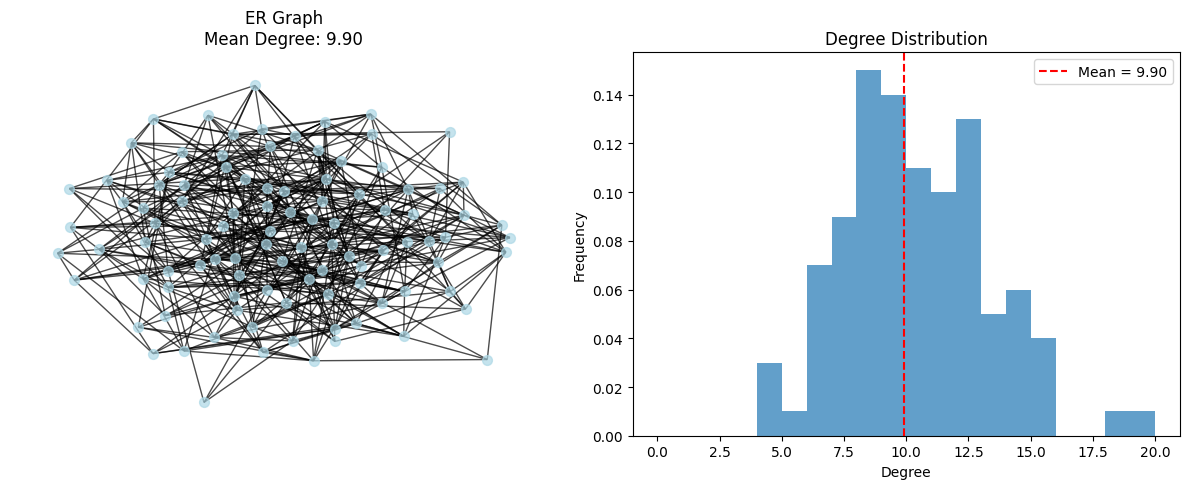

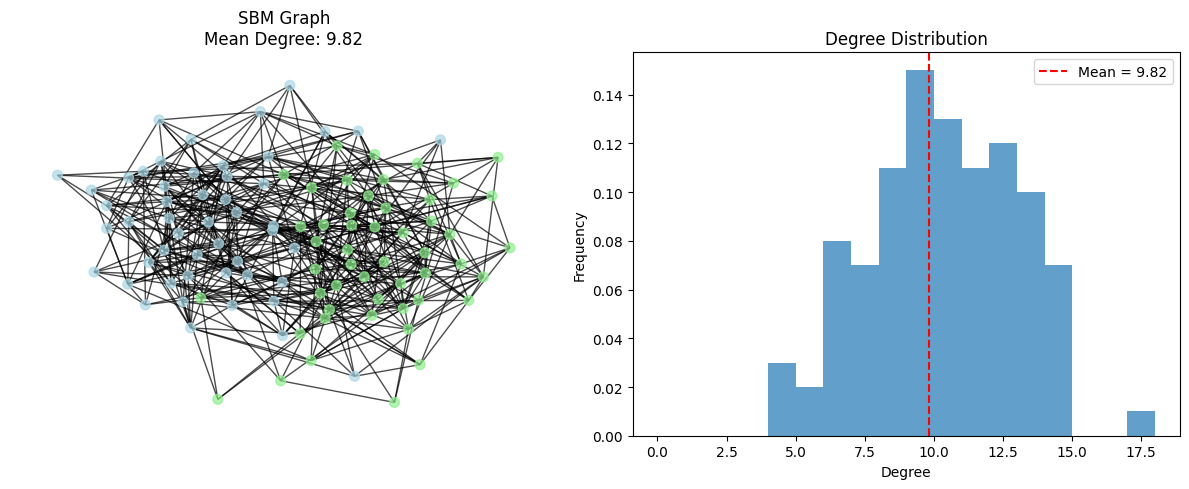

In [49]:
def create_deterministic_er_graph(n=100, p=0.1, seed=42):
    """Create deterministic ER graph with specified parameters"""
    np.random.seed(seed)
    
    # Create adjacency matrix
    adj_matrix = np.zeros((n, n))
    target_edges = int(n * (n-1) * p / 2)  # Total number of edges in graph
    
    # Create all possible edges
    edges = [(i, j) for i in range(n) for j in range(i+1, n)]
    selected_edges = np.random.choice(len(edges), target_edges, replace=False)
    
    # Add selected edges
    for idx in selected_edges:
        i, j = edges[idx]
        adj_matrix[i, j] = adj_matrix[j, i] = 1
    
    # Make symmetric
    adj_matrix = np.maximum(adj_matrix, adj_matrix.T)
    
    # Create graph from adjacency matrix
    G = nx.from_numpy_array(adj_matrix)
    degrees = [d for _, d in G.degree()]
    mean_degree = np.mean(degrees)
    
    plt.figure(figsize=(12, 5))
    plt.subplot(121)
    nx.draw(G, node_size=50, node_color='lightblue', 
            with_labels=False, alpha=0.7)
    plt.title(f'ER Graph\nMean Degree: {mean_degree:.2f}')
    
    plt.subplot(122)
    plt.hist(degrees, bins=range(max(degrees)+2), density=True, alpha=0.7)
    plt.axvline(mean_degree, color='r', linestyle='--', 
                label=f'Mean = {mean_degree:.2f}')
    plt.title('Degree Distribution')
    plt.xlabel('Degree')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return G

def create_deterministic_sbm_graph(seed=42, p_within=0.15, p_between=0.05):
    """Create deterministic SBM graph with two communities"""
    np.random.seed(seed)
    n_per_community = 50
    
    # Initialize full adjacency matrix
    adj_matrix = np.zeros((2*n_per_community, 2*n_per_community))
    
    # Add within-community edges for each community
    for comm_start in [0, n_per_community]:
        edges = [(i, j) for i in range(comm_start, comm_start + n_per_community) 
                for j in range(i+1, comm_start + n_per_community)]
        target_within_edges = int(n_per_community * (n_per_community-1) * p_within / 2)
        selected_edges = np.random.choice(len(edges), target_within_edges, replace=False)
        
        for idx in selected_edges:
            i, j = edges[idx]
            adj_matrix[i, j] = adj_matrix[j, i] = 1
    
    # Add between-community connections
    target_between_edges = int(n_per_community * n_per_community * p_between)
    possible_between_edges = [(i, j+n_per_community) 
                            for i in range(n_per_community) 
                            for j in range(n_per_community)]
    selected_edges = np.random.choice(len(possible_between_edges), 
                                    target_between_edges, replace=False)
    
    for idx in selected_edges:
        i, j = possible_between_edges[idx]
        adj_matrix[i, j] = 1
    
    # Make symmetric
    adj_matrix = np.maximum(adj_matrix, adj_matrix.T)
    
    # Create graph from adjacency matrix
    G = nx.from_numpy_array(adj_matrix)
    degrees = [d for _, d in G.degree()]
    mean_degree = np.mean(degrees)
    
    plt.figure(figsize=(12, 5))
    plt.subplot(121)
    pos = nx.spring_layout(G, seed=seed)
    colors = ['lightblue']*n_per_community + ['lightgreen']*n_per_community
    nx.draw(G, pos, node_color=colors, node_size=50, 
            with_labels=False, alpha=0.7)
    plt.title(f'SBM Graph\nMean Degree: {mean_degree:.2f}')
    
    plt.subplot(122)
    plt.hist(degrees, bins=range(max(degrees)+2), density=True, alpha=0.7)
    plt.axvline(mean_degree, color='r', linestyle='--', 
                label=f'Mean = {mean_degree:.2f}')
    plt.title('Degree Distribution')
    plt.xlabel('Degree')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return G


ERSBM1_er = create_deterministic_er_graph()
ERSBM1_sbm = create_deterministic_sbm_graph()

In [50]:
ERSBM1_erproto2 = compute_distance_matrix(ERSBM1_er)
ERSBM1_sbmproto2 = compute_distance_matrix(ERSBM1_sbm)

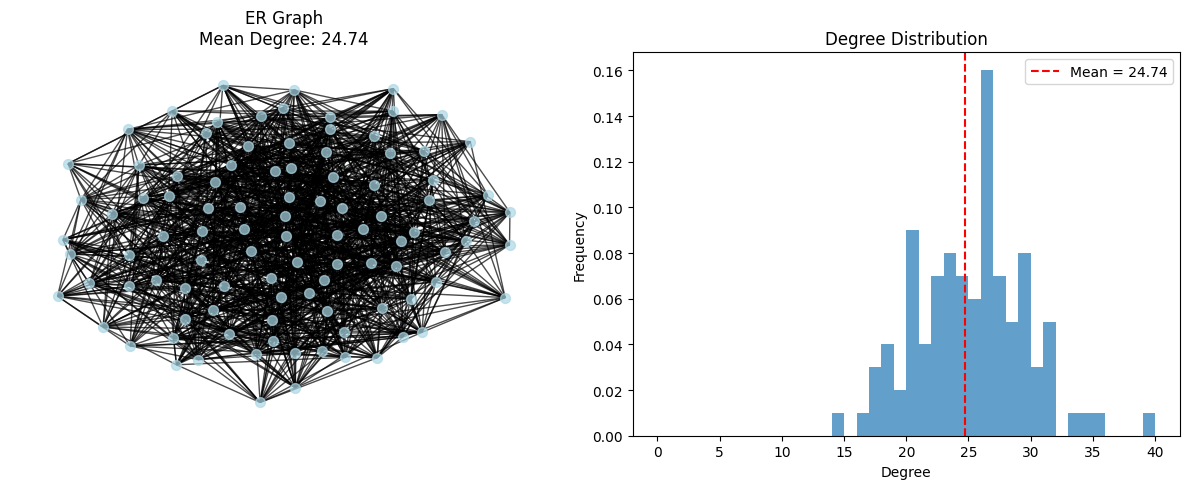

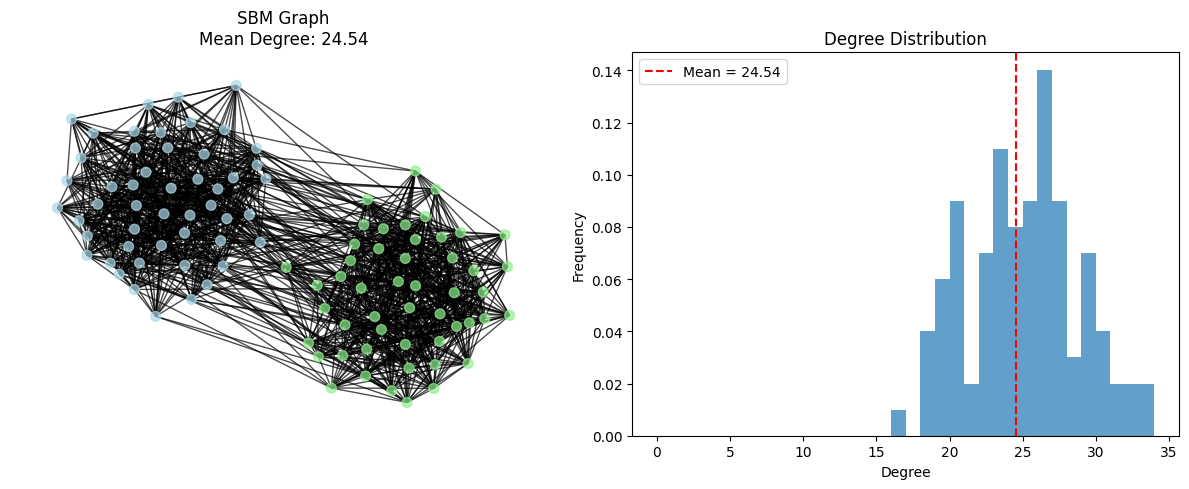

In [51]:
ERSBM2_er = create_deterministic_er_graph(p=0.25)
ERSBM2_sbm = create_deterministic_sbm_graph(p_within=0.45, p_between=0.05)

In [52]:
ERSBM2_erproto2 = compute_distance_matrix(ERSBM2_er)
ERSBM2_sbmproto2 = compute_distance_matrix(ERSBM2_sbm)

In [53]:
ERSBM1_exp2 = gw_barycenter_class_alg_prototypes(distance_matrices, ERSBM1_sbmproto2, ERSBM1_erproto2, labels, 10, method="kfold")

k-fold CV selected
Fold 0:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.508800000000002  Fold 0
F1 Score (macro avg): 48.717948717948715%, Fold 0
Classification Accuracy: 55.00000000000001% Fold 0
Classification Accuracy for Class -1: 20.0% Fold 0
Classification Accuracy for Class 1: 90.0% Fold 0
Fold 1:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.508800000000002  Fold 1
F1 Score (macro avg): 52.38095238095239%, Fold 1
Classification Accuracy: 60.0% Fold 1
Classification Accuracy for Class -1: 22.22222222222222% Fold 1
Classification Accuracy for Class 1: 90.9090909090909% Fold 1
Fold 2:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.508800000000002  Fold 2
F1 Score (macro avg): 54.88721804511278%, Fold 2
Classification Accuracy: 55.00000000000001% Fold 2
Classification A

In [55]:
ERSBM2_exp2 = gw_barycenter_class_alg_prototypes(distance_matrices5, ERSBM2_sbmproto2, ERSBM2_erproto2, labels5, 10, method="kfold")

k-fold CV selected
Fold 0:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.3396000000000016  Fold 0
F1 Score (macro avg): 84.65473145780051%, Fold 0
Classification Accuracy: 85.0% Fold 0
Classification Accuracy for Class -1: 70.0% Fold 0
Classification Accuracy for Class 1: 100.0% Fold 0
Fold 1:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.3396000000000016  Fold 1
F1 Score (macro avg): 94.8849104859335%, Fold 1
Classification Accuracy: 95.0% Fold 1
Classification Accuracy for Class -1: 88.88888888888889% Fold 1
Classification Accuracy for Class 1: 100.0% Fold 1
Fold 2:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.3396000000000016  Fold 2
F1 Score (macro avg): 79.16666666666667%, Fold 2
Classification Accuracy: 80.0% Fold 2
Classification Accuracy for Class -1: 60.0% Fold 2


In [56]:
# Attempt 3: Create fully-connected graphs with edge weights that reflect EAPs in each graph model
def create_two_community_graph(nodes_per_community, weight_in_comm, weight_bt_comm):
    # Create an empty graph
    G = nx.Graph()
    
    total_nodes = nodes_per_community * 2
    G.add_nodes_from(range(total_nodes))
    
    # Add edges within communities
    for comm in range(2):
        start = comm * nodes_per_community
        end = start + nodes_per_community
        for i in range(start, end):
            for j in range(i + 1, end):
                G.add_edge(i, j, weight=weight_in_comm)
    
    # Add edges between communities
    for i in range(nodes_per_community):
        for j in range(nodes_per_community):
            G.add_edge(i, j + nodes_per_community, weight=weight_bt_comm)
    
    # Create the adjacency matrix
    adjacency_matrix = np.zeros((total_nodes, total_nodes))
    
    # Fill the matrix according to the block structure
    for i in range(total_nodes):
        for j in range(total_nodes):
            if i == j:
                # Diagonal entries are 0
                adjacency_matrix[i, j] = 0.0
            elif (i < nodes_per_community and j < nodes_per_community) or \
                 (i >= nodes_per_community and j >= nodes_per_community):
                # Within same community
                adjacency_matrix[i, j] = weight_in_comm
            else:
                # Between different communities
                adjacency_matrix[i, j] = weight_bt_comm

    return G, adjacency_matrix


def compute_adjacency_matrix(graph, weight_within, weight_bt):
    """
    Computes the weighted adjacency matrix for a given graph.

    Args:
        graph: A NetworkX graph.
        weight_within: Weight to assign to edges within the same community. 
                      If None, uses the graph's edge weights.
        weight_bt: Weight to assign to edges between different communities.
                  If None, uses the graph's edge weights.

    Returns:
        A numpy array representing the weighted adjacency matrix where the value 
        at (i, j) denotes the weight of the edge between node i and node j.
    """
    import numpy as np
    
    # Initialize a matrix of zeros
    num_nodes = len(graph.nodes)
    adjacency_matrix = np.zeros((num_nodes, num_nodes), dtype=float)
    
    # Assume two communities of equal size
    nodes_per_community = num_nodes // 2

    # Populate the adjacency matrix
    for i, node_i in enumerate(graph.nodes()):
        for j, node_j in enumerate(graph.nodes()):
            if graph.has_edge(node_i, node_j):
                # Determine if nodes are in the same community
                comm_i = node_i // nodes_per_community
                comm_j = node_j // nodes_per_community
                
                if weight_within is not None and weight_bt is not None:
                    # Use user-defined weights
                    if comm_i == comm_j:
                        adjacency_matrix[i, j] = weight_within
                    else:
                        adjacency_matrix[i, j] = weight_bt
                else:
                    # Use original graph weights
                    edge_data = graph.get_edge_data(node_i, node_j)
                    adjacency_matrix[i, j] = edge_data['weight']

    return adjacency_matrix

In [57]:
graph1, ERSBM1_proto_ER = create_two_community_graph(50, 0.1, 0.1)
graph2, ERSBM1_proto_SBM = create_two_community_graph(50, 0.15, 0.05)
graph3, ERSBM2_proto_ER = create_two_community_graph(50, 0.25, 0.25)
graph4, ERSBM2_proto_SBM = create_two_community_graph(50, 0.45, 0.05)

In [58]:
ERSBM1_adj_er = [
    compute_adjacency_matrix(graph, 0.1, 0.1) for graph, label in graphs_er
]
ERSBM1_adj_sbm = [
    compute_adjacency_matrix(graph, 0.15, 0.05) for graph, label in graphs_sbm
]
ERSBM2_adj_er5 = [
    compute_adjacency_matrix(graph5, 0.25, 0.25) for graph5, label5 in graphs_er5
]
ERSBM2_adj_sbm5 = [
    compute_adjacency_matrix(graph5, 0.45, 0.05) for graph5, label5 in graphs_sbm5
]

In [59]:
ERSBM1_adj = ERSBM1_adj_er + ERSBM1_adj_sbm
ERSBM2_adj = ERSBM2_adj_er5 + ERSBM2_adj_sbm5

In [60]:
ERSBM1_exp3 = gw_barycenter_class_alg_prototypes(ERSBM1_adj, ERSBM1_proto_SBM, ERSBM1_proto_ER, labels, 10, method="kfold")

k-fold CV selected
Fold 0:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.0024750000000000037  Fold 0
F1 Score (macro avg): 33.33333333333333%, Fold 0
Classification Accuracy: 50.0% Fold 0
Classification Accuracy for Class -1: 0.0% Fold 0
Classification Accuracy for Class 1: 100.0% Fold 0
Fold 1:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.0024750000000000037  Fold 1
F1 Score (macro avg): 35.483870967741936%, Fold 1
Classification Accuracy: 55.00000000000001% Fold 1
Classification Accuracy for Class -1: 0.0% Fold 1
Classification Accuracy for Class 1: 100.0% Fold 1
Fold 2:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.0024750000000000037  Fold 2
F1 Score (macro avg): 33.33333333333333%, Fold 2
Classification Accuracy: 50.0% Fold 2
Classification Accuracy for Class -1: 0.0%

In [61]:
ERSBM2_exp3 = gw_barycenter_class_alg_prototypes(ERSBM2_adj, ERSBM2_proto_SBM, ERSBM2_proto_ER, labels5, 10, method="kfold")

k-fold CV selected
Fold 0:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.03959999999999981  Fold 0
F1 Score (macro avg): 67.03296703296704%, Fold 0
Classification Accuracy: 70.0% Fold 0
Classification Accuracy for Class -1: 40.0% Fold 0
Classification Accuracy for Class 1: 100.0% Fold 0
Fold 1:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.03959999999999981  Fold 1
F1 Score (macro avg): 89.58333333333333%, Fold 1
Classification Accuracy: 90.0% Fold 1
Classification Accuracy for Class -1: 77.77777777777779% Fold 1
Classification Accuracy for Class 1: 100.0% Fold 1
Fold 2:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.03959999999999981  Fold 2
F1 Score (macro avg): 89.8989898989899%, Fold 2
Classification Accuracy: 90.0% Fold 2
Classification Accuracy for Class -1: 80.0% Fold

In [62]:
# Attempt 4: Smaller prototypes
def create_self_loop_graph(weight_within, weight_bt):
    # Create a graph with two nodes, self-loops, and one connecting edge
    G = nx.Graph()
    G.add_nodes_from([0, 1])
    # Add self-loops
    G.add_edge(0, 0, weight=weight_within)
    G.add_edge(1, 1, weight=weight_within)
    # Add connecting edge
    G.add_edge(0, 1, weight=weight_bt)
    
    # Create the adjacency matrix
    adjacency_matrix = np.zeros((2, 2))
    adjacency_matrix[0, 0] = weight_within  # Self-loop for node 0
    adjacency_matrix[1, 1] = weight_within  # Self-loop for node 1
    adjacency_matrix[0, 1] = weight_bt      # Edge between nodes
    adjacency_matrix[1, 0] = weight_bt      # Edge between nodes (symmetric)
    
    return G, adjacency_matrix

In [63]:
graph10, ERSBM1_proto_ER2 = create_self_loop_graph(weight_within=0.1, weight_bt=0.1)
graph11, ERSBM1_proto_SBM2 = create_self_loop_graph(weight_within=0.15, weight_bt=0.05)
graph12, ERSBM2_proto_ER2 = create_self_loop_graph(weight_within=0.25, weight_bt=0.25)
graph13, ERSBM2_proto_SBM2 = create_self_loop_graph(weight_within=0.45, weight_bt=0.05)

In [64]:
ERSBM1_exp4 = gw_barycenter_class_alg_prototypes(ERSBM1_adj, ERSBM1_proto_SBM2, ERSBM1_proto_ER2, labels, 10, method="kfold")

k-fold CV selected
Fold 0:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.0024999999999999988  Fold 0
F1 Score (macro avg): 33.33333333333333%, Fold 0
Classification Accuracy: 50.0% Fold 0
Classification Accuracy for Class -1: 0.0% Fold 0
Classification Accuracy for Class 1: 100.0% Fold 0
Fold 1:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.0024999999999999988  Fold 1
F1 Score (macro avg): 35.483870967741936%, Fold 1
Classification Accuracy: 55.00000000000001% Fold 1
Classification Accuracy for Class -1: 0.0% Fold 1
Classification Accuracy for Class 1: 100.0% Fold 1
Fold 2:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.0024999999999999988  Fold 2
F1 Score (macro avg): 33.33333333333333%, Fold 2
Classification Accuracy: 50.0% Fold 2
Classification Accuracy for Class -1: 0.0%

In [65]:
ERSBM2_exp4 = gw_barycenter_class_alg_prototypes(ERSBM2_adj, ERSBM2_proto_SBM2, ERSBM2_proto_ER2, labels5, 10, method="kfold")

k-fold CV selected
Fold 0:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.04000000000000001  Fold 0
F1 Score (macro avg): 43.57366771159875%, Fold 0
Classification Accuracy: 55.00000000000001% Fold 0
Classification Accuracy for Class -1: 10.0% Fold 0
Classification Accuracy for Class 1: 100.0% Fold 0
Fold 1:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.04000000000000001  Fold 1
F1 Score (macro avg): 35.483870967741936%, Fold 1
Classification Accuracy: 55.00000000000001% Fold 1
Classification Accuracy for Class -1: 0.0% Fold 1
Classification Accuracy for Class 1: 100.0% Fold 1
Fold 2:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.04000000000000001  Fold 2
F1 Score (macro avg): 43.57366771159875%, Fold 2
Classification Accuracy: 55.00000000000001% Fold 2
Classification Accura

In [66]:
### SCATTERPLOTS OF PROTOTYPE DISTANCES (LARGER PROTOYPES) ###
def compute_gromov_wasserstein_distance(adj_matrix1, adj_matrix2):
    """
    Compute the Gromov-Wasserstein distance between two adjacency matrices.
    
    Args:
        adj_matrix1: First adjacency matrix
        adj_matrix2: Second adjacency matrix
    
    Returns:
        The Gromov-Wasserstein distance
    """
    n1, n2 = adj_matrix1.shape[0], adj_matrix2.shape[0]
    
    # Create uniform distributions
    p = np.ones(n1) / n1
    q = np.ones(n2) / n2
    
    # Compute Gromov-Wasserstein distance
    gw_dist = ot.gromov.gromov_wasserstein2(adj_matrix1, adj_matrix2, p, q, 'square_loss')
    
    return np.sqrt(gw_dist)

# Compute Gromov-Wasserstein distances for ERSBM1
print("Computing Gromov-Wasserstein distances for ERSBM1...")

# Distances from ERSBM1 graphs to ER prototype
gw_distances_er_to_er_proto = []
gw_distances_sbm_to_er_proto = []

for adj_matrix in ERSBM1_adj_er:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM1_proto_ER)
    gw_distances_er_to_er_proto.append(dist)

for adj_matrix in ERSBM1_adj_sbm:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM1_proto_ER)
    gw_distances_sbm_to_er_proto.append(dist)

# Distances from ERSBM1 graphs to SBM prototype
gw_distances_er_to_sbm_proto = []
gw_distances_sbm_to_sbm_proto = []

for adj_matrix in ERSBM1_adj_er:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM1_proto_SBM)
    gw_distances_er_to_sbm_proto.append(dist)

for adj_matrix in ERSBM1_adj_sbm:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM1_proto_SBM)
    gw_distances_sbm_to_sbm_proto.append(dist)

Computing Gromov-Wasserstein distances for ERSBM1...


In [67]:
# Compute Gromov-Wasserstein distances for ERSBM2
print("Computing Gromov-Wasserstein distances for ERSBM2...")

# Distances from ERSBM2 graphs to ER prototype
gw_distances_er5_to_er_proto = []
gw_distances_sbm5_to_er_proto = []

for adj_matrix in ERSBM2_adj_er5:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM2_proto_ER)
    gw_distances_er5_to_er_proto.append(dist)

for adj_matrix in ERSBM2_adj_sbm5:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM2_proto_ER)
    gw_distances_sbm5_to_er_proto.append(dist)

# Distances from ERSBM2 graphs to SBM prototype
gw_distances_er5_to_sbm_proto = []
gw_distances_sbm5_to_sbm_proto = []

for adj_matrix in ERSBM2_adj_er5:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM2_proto_SBM)
    gw_distances_er5_to_sbm_proto.append(dist)

for adj_matrix in ERSBM2_adj_sbm5:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM2_proto_SBM)
    gw_distances_sbm5_to_sbm_proto.append(dist)

Computing Gromov-Wasserstein distances for ERSBM2...


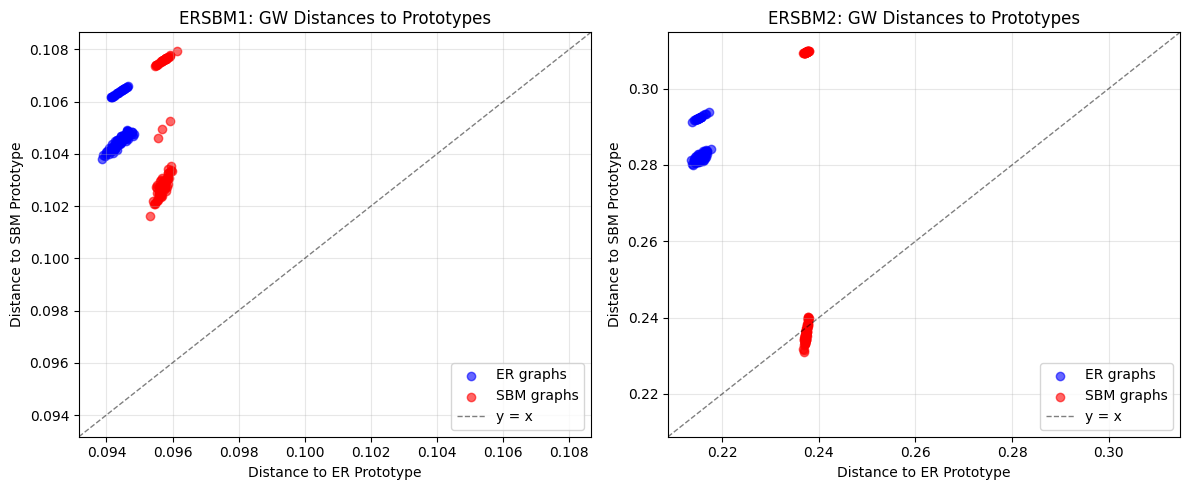

In [68]:
# Calculate axis limits for ERSBM1
ersbm1_distances = (gw_distances_er_to_er_proto + gw_distances_sbm_to_er_proto +
                   gw_distances_er_to_sbm_proto + gw_distances_sbm_to_sbm_proto)

min_dist_ersbm1 = min(ersbm1_distances)
max_dist_ersbm1 = max(ersbm1_distances)
margin_ersbm1 = (max_dist_ersbm1 - min_dist_ersbm1) * 0.05  # Add 5% margin

axis_min_ersbm1 = min_dist_ersbm1 - margin_ersbm1
axis_max_ersbm1 = max_dist_ersbm1 + margin_ersbm1

# Calculate axis limits for ERSBM2
ersbm2_distances = (gw_distances_er5_to_er_proto + gw_distances_sbm5_to_er_proto +
                   gw_distances_er5_to_sbm_proto + gw_distances_sbm5_to_sbm_proto)

min_dist_ersbm2 = min(ersbm2_distances)
max_dist_ersbm2 = max(ersbm2_distances)
margin_ersbm2 = (max_dist_ersbm2 - min_dist_ersbm2) * 0.05  # Add 5% margin

axis_min_ersbm2 = min_dist_ersbm2 - margin_ersbm2
axis_max_ersbm2 = max_dist_ersbm2 + margin_ersbm2

# Plot results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(gw_distances_er_to_er_proto, gw_distances_er_to_sbm_proto, 
           alpha=0.6, label='ER graphs', color='blue')
plt.scatter(gw_distances_sbm_to_er_proto, gw_distances_sbm_to_sbm_proto, 
           alpha=0.6, label='SBM graphs', color='red')
# Add diagonal line
plt.plot([axis_min_ersbm1, axis_max_ersbm1], [axis_min_ersbm1, axis_max_ersbm1], 'k--', alpha=0.5, linewidth=1, label='y = x')
plt.xlim(axis_min_ersbm1, axis_max_ersbm1)
plt.ylim(axis_min_ersbm1, axis_max_ersbm1)
plt.xlabel('Distance to ER Prototype')
plt.ylabel('Distance to SBM Prototype')
plt.title('ERSBM1: GW Distances to Prototypes')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(gw_distances_er5_to_er_proto, gw_distances_er5_to_sbm_proto, 
           alpha=0.6, label='ER graphs', color='blue')
plt.scatter(gw_distances_sbm5_to_er_proto, gw_distances_sbm5_to_sbm_proto, 
           alpha=0.6, label='SBM graphs', color='red')
# Add diagonal line
plt.plot([axis_min_ersbm2, axis_max_ersbm2], [axis_min_ersbm2, axis_max_ersbm2], 'k--', alpha=0.5, linewidth=1, label='y = x')
plt.xlim(axis_min_ersbm2, axis_max_ersbm2)
plt.ylim(axis_min_ersbm2, axis_max_ersbm2)
plt.xlabel('Distance to ER Prototype')
plt.ylabel('Distance to SBM Prototype')
plt.title('ERSBM2: GW Distances to Prototypes')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [69]:
# Print some statistics
print("\nERSBM1 Statistics:")
print(f"ER graphs - Mean distance to ER prototype: {np.mean(gw_distances_er_to_er_proto):.4f}")
print(f"ER graphs - Mean distance to SBM prototype: {np.mean(gw_distances_er_to_sbm_proto):.4f}")
print(f"SBM graphs - Mean distance to ER prototype: {np.mean(gw_distances_sbm_to_er_proto):.4f}")
print(f"SBM graphs - Mean distance to SBM prototype: {np.mean(gw_distances_sbm_to_sbm_proto):.4f}")

print("\nERSBM2 Statistics:")
print(f"ER graphs - Mean distance to ER prototype: {np.mean(gw_distances_er5_to_er_proto):.4f}")
print(f"ER graphs - Mean distance to SBM prototype: {np.mean(gw_distances_er5_to_sbm_proto):.4f}")
print(f"SBM graphs - Mean distance to ER prototype: {np.mean(gw_distances_sbm5_to_er_proto):.4f}")
print(f"SBM graphs - Mean distance to SBM prototype: {np.mean(gw_distances_sbm5_to_sbm_proto):.4f}")


ERSBM1 Statistics:
ER graphs - Mean distance to ER prototype: 0.0944
ER graphs - Mean distance to SBM prototype: 0.1050
SBM graphs - Mean distance to ER prototype: 0.0957
SBM graphs - Mean distance to SBM prototype: 0.1044

ERSBM2 Statistics:
ER graphs - Mean distance to ER prototype: 0.2154
ER graphs - Mean distance to SBM prototype: 0.2845
SBM graphs - Mean distance to ER prototype: 0.2374
SBM graphs - Mean distance to SBM prototype: 0.2566


In [70]:
### SCATTERPLOTS OF PROTOTYPE DISTANCES (SMALLER PROTOYPES) ###
# Compute Gromov-Wasserstein distances for ERSBM1
print("Computing Gromov-Wasserstein distances for ERSBM1...")

# Distances from ERSBM1 graphs to ER prototype
gw_distances_er_to_er_proto = []
gw_distances_sbm_to_er_proto = []

for adj_matrix in ERSBM1_adj_er:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM1_proto_ER2)
    gw_distances_er_to_er_proto.append(dist)

for adj_matrix in ERSBM1_adj_sbm:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM1_proto_ER2)
    gw_distances_sbm_to_er_proto.append(dist)

# Distances from ERSBM1 graphs to SBM prototype
gw_distances_er_to_sbm_proto = []
gw_distances_sbm_to_sbm_proto = []

for adj_matrix in ERSBM1_adj_er:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM1_proto_SBM2)
    gw_distances_er_to_sbm_proto.append(dist)

for adj_matrix in ERSBM1_adj_sbm:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM1_proto_SBM2)
    gw_distances_sbm_to_sbm_proto.append(dist)

Computing Gromov-Wasserstein distances for ERSBM1...


In [71]:
# Compute Gromov-Wasserstein distances for ERSBM2
print("Computing Gromov-Wasserstein distances for ERSBM2...")

# Distances from ERSBM2 graphs to ER prototype
gw_distances_er5_to_er_proto = []
gw_distances_sbm5_to_er_proto = []

for adj_matrix in ERSBM2_adj_er5:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM2_proto_ER2)
    gw_distances_er5_to_er_proto.append(dist)

for adj_matrix in ERSBM2_adj_sbm5:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM2_proto_ER2)
    gw_distances_sbm5_to_er_proto.append(dist)

# Distances from ERSBM2 graphs to SBM prototype
gw_distances_er5_to_sbm_proto = []
gw_distances_sbm5_to_sbm_proto = []

for adj_matrix in ERSBM2_adj_er5:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM2_proto_SBM2)
    gw_distances_er5_to_sbm_proto.append(dist)

for adj_matrix in ERSBM2_adj_sbm5:
    dist = compute_gromov_wasserstein_distance(adj_matrix, ERSBM2_proto_SBM2)
    gw_distances_sbm5_to_sbm_proto.append(dist)

Computing Gromov-Wasserstein distances for ERSBM2...


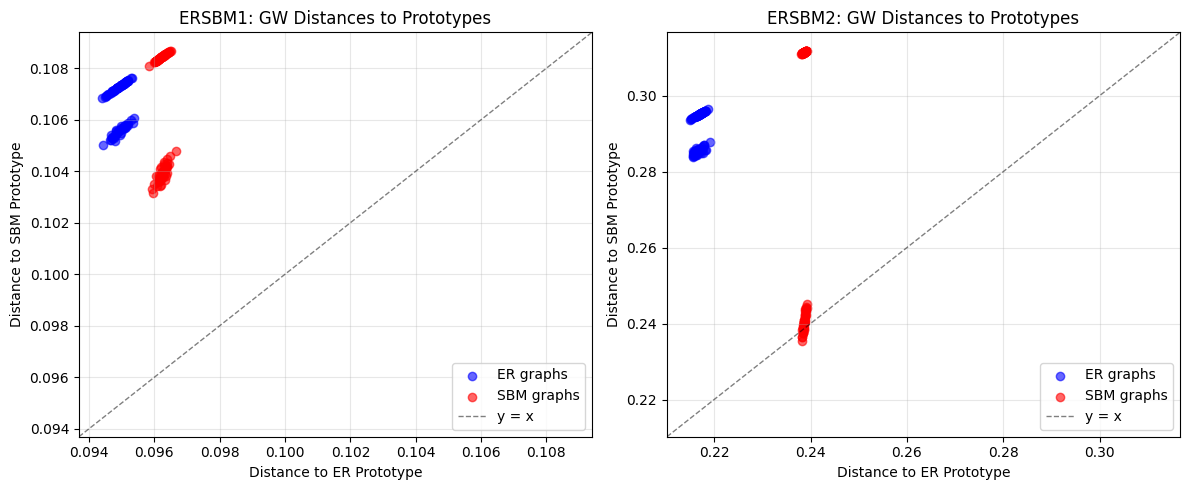

In [72]:
# Calculate axis limits for ERSBM1
ersbm1_distances = (gw_distances_er_to_er_proto + gw_distances_sbm_to_er_proto +
                   gw_distances_er_to_sbm_proto + gw_distances_sbm_to_sbm_proto)

min_dist_ersbm1 = min(ersbm1_distances)
max_dist_ersbm1 = max(ersbm1_distances)
margin_ersbm1 = (max_dist_ersbm1 - min_dist_ersbm1) * 0.05  # Add 5% margin

axis_min_ersbm1 = min_dist_ersbm1 - margin_ersbm1
axis_max_ersbm1 = max_dist_ersbm1 + margin_ersbm1

# Calculate axis limits for ERSBM2
ersbm2_distances = (gw_distances_er5_to_er_proto + gw_distances_sbm5_to_er_proto +
                   gw_distances_er5_to_sbm_proto + gw_distances_sbm5_to_sbm_proto)

min_dist_ersbm2 = min(ersbm2_distances)
max_dist_ersbm2 = max(ersbm2_distances)
margin_ersbm2 = (max_dist_ersbm2 - min_dist_ersbm2) * 0.05  # Add 5% margin

axis_min_ersbm2 = min_dist_ersbm2 - margin_ersbm2
axis_max_ersbm2 = max_dist_ersbm2 + margin_ersbm2

# Plot results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(gw_distances_er_to_er_proto, gw_distances_er_to_sbm_proto, 
           alpha=0.6, label='ER graphs', color='blue')
plt.scatter(gw_distances_sbm_to_er_proto, gw_distances_sbm_to_sbm_proto, 
           alpha=0.6, label='SBM graphs', color='red')
# Add diagonal line
plt.plot([axis_min_ersbm1, axis_max_ersbm1], [axis_min_ersbm1, axis_max_ersbm1], 'k--', alpha=0.5, linewidth=1, label='y = x')
plt.xlim(axis_min_ersbm1, axis_max_ersbm1)
plt.ylim(axis_min_ersbm1, axis_max_ersbm1)
plt.xlabel('Distance to ER Prototype')
plt.ylabel('Distance to SBM Prototype')
plt.title('ERSBM1: GW Distances to Prototypes')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(gw_distances_er5_to_er_proto, gw_distances_er5_to_sbm_proto, 
           alpha=0.6, label='ER graphs', color='blue')
plt.scatter(gw_distances_sbm5_to_er_proto, gw_distances_sbm5_to_sbm_proto, 
           alpha=0.6, label='SBM graphs', color='red')
# Add diagonal line
plt.plot([axis_min_ersbm2, axis_max_ersbm2], [axis_min_ersbm2, axis_max_ersbm2], 'k--', alpha=0.5, linewidth=1, label='y = x')
plt.xlim(axis_min_ersbm2, axis_max_ersbm2)
plt.ylim(axis_min_ersbm2, axis_max_ersbm2)
plt.xlabel('Distance to ER Prototype')
plt.ylabel('Distance to SBM Prototype')
plt.title('ERSBM2: GW Distances to Prototypes')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [73]:
# Print some statistics
print("\nERSBM1 Statistics:")
print(f"ER graphs - Mean distance to ER prototype: {np.mean(gw_distances_er_to_er_proto):.4f}")
print(f"ER graphs - Mean distance to SBM prototype: {np.mean(gw_distances_er_to_sbm_proto):.4f}")
print(f"SBM graphs - Mean distance to ER prototype: {np.mean(gw_distances_sbm_to_er_proto):.4f}")
print(f"SBM graphs - Mean distance to SBM prototype: {np.mean(gw_distances_sbm_to_sbm_proto):.4f}")

print("\nERSBM2 Statistics:")
print(f"ER graphs - Mean distance to ER prototype: {np.mean(gw_distances_er5_to_er_proto):.4f}")
print(f"ER graphs - Mean distance to SBM prototype: {np.mean(gw_distances_er5_to_sbm_proto):.4f}")
print(f"SBM graphs - Mean distance to ER prototype: {np.mean(gw_distances_sbm5_to_er_proto):.4f}")
print(f"SBM graphs - Mean distance to SBM prototype: {np.mean(gw_distances_sbm5_to_sbm_proto):.4f}")


ERSBM1 Statistics:
ER graphs - Mean distance to ER prototype: 0.0949
ER graphs - Mean distance to SBM prototype: 0.1066
SBM graphs - Mean distance to ER prototype: 0.0962
SBM graphs - Mean distance to SBM prototype: 0.1065

ERSBM2 Statistics:
ER graphs - Mean distance to ER prototype: 0.2169
ER graphs - Mean distance to SBM prototype: 0.2913
SBM graphs - Mean distance to ER prototype: 0.2387
SBM graphs - Mean distance to SBM prototype: 0.2838
